In [1]:
import pandas as pd
import numpy as np
from IPython.core.pylabtools import figsize
from matplotlib import pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsforecast.arima import AutoARIMA
from statsmodels.tsa.seasonal import MSTL

from  dataset import get_oil_weekly_prices
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
from sklearn.metrics import mean_squared_log_error

/home/rishabh/miniconda3/envs/ts-env/lib/python3.12/site-packages/dask/dataframe/__init__.py:49: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


# Engineering temporal features
### 1. Introduction
- Overview of the dataset(weekly oil prices from 1986 to 2025)

In [2]:
df = get_oil_weekly_prices()
y = df
y.head()

,closing
date,
1986-01-03,26.00
1986-01-10,25.65
1986-01-17,23.63
1986-01-24,19.45
1986-01-31,18.95


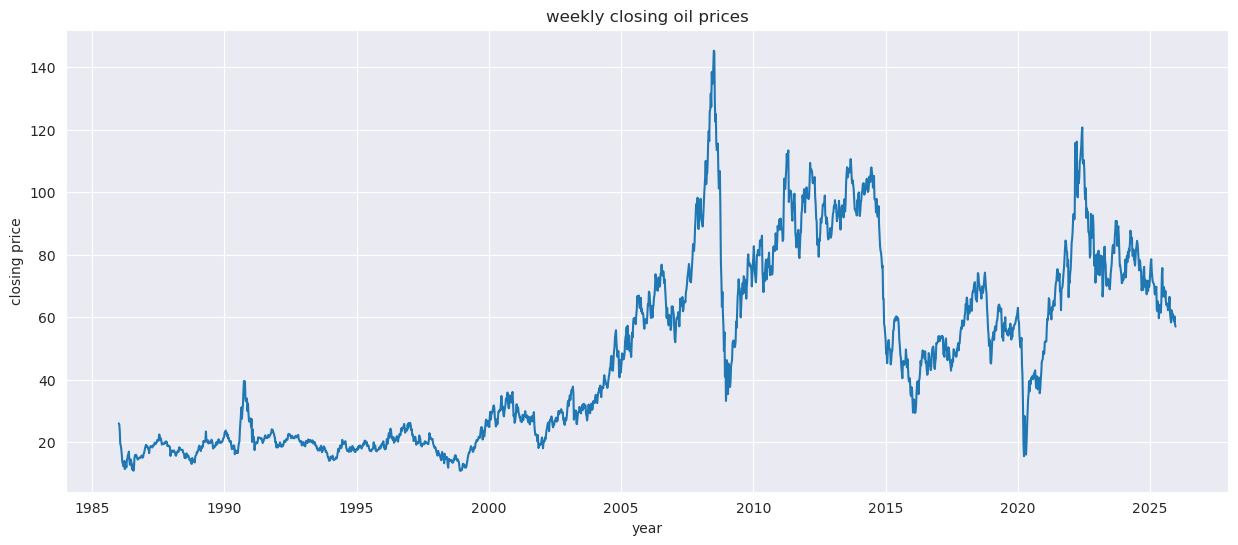

In [3]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(y['closing'])
ax.set(xlabel='year', ylabel='closing price')
ax.title.set_text('weekly closing oil prices')
plt.show()

- The plot shows patterns of growth and decay which are not well characterised by trend or seasons.
- Therefore, we model cycles in the price of oil using lag features

### 2. Feature Engineering
- **Lag Features**: Capturing autoregressive patterns with lagged values

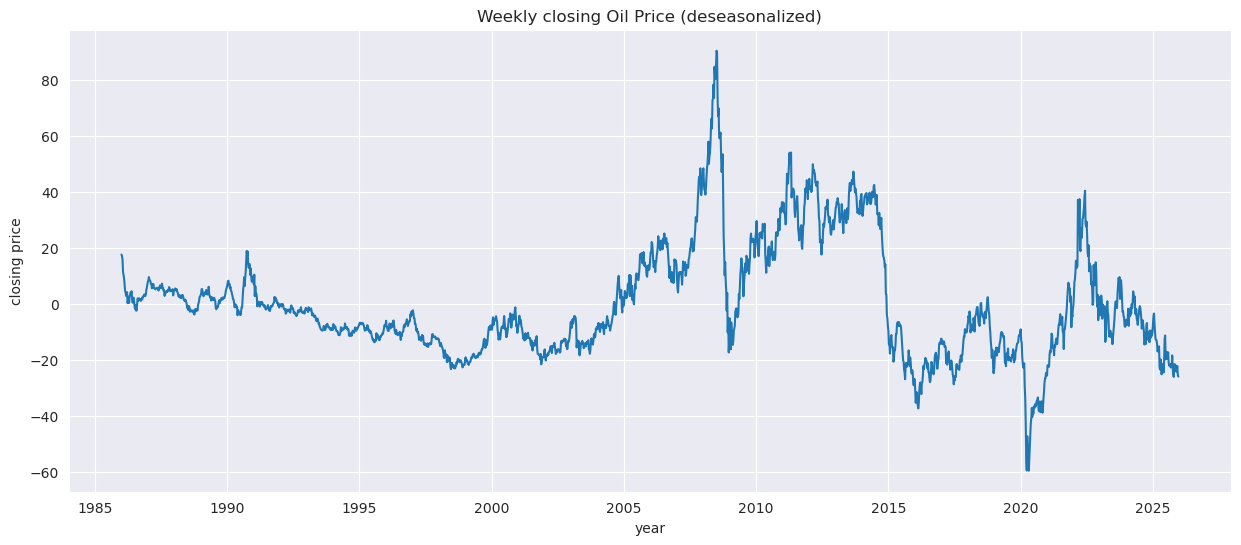

In [4]:
fourier = CalendarFourier(freq='W', order=4)
# order = 1 will capture the trend in the time series
dp = DeterministicProcess(
    constant=True,
    index=y.index,
    order=1,
    seasonal=True,
    drop=True,
    additional_terms=[fourier],
)
X_time = dp.in_sample()

model = LinearRegression(fit_intercept=False)
model.fit(X_time, y)
y_deseason = y - model.predict(X_time)
y_deseason.name = 'oil_price_deseasoned'

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(y_deseason['closing'])
ax.set(xlabel='year', ylabel='closing price')
ax.set_title("Weekly closing Oil Price (deseasonalized)")
plt.show()

[Text(0.5, 24.0, 'year'), Text(24.000000000000007, 0.5, 'closing price')]

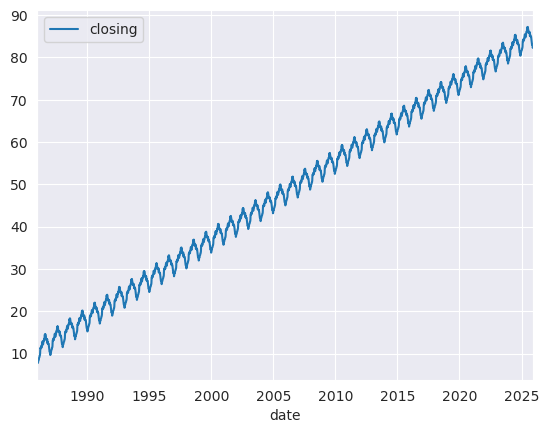

In [5]:
# seasonal component in the oil price time series
y_diff = y - y_deseason
y_diff.plot()
ax.set(xlabel='year', ylabel='closing price')

- To confirm our intuition, we try to isolate cyclic behavior using moving-average, where we take a yearly window.

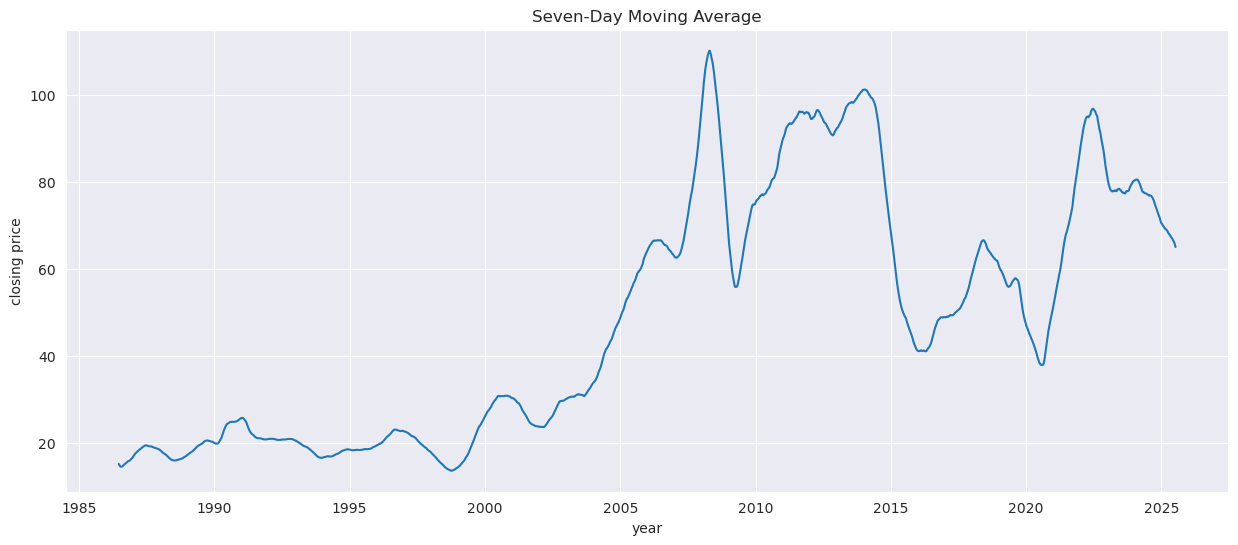

In [6]:
y_ma = y.rolling(
    window=4*12,
    center=True).mean()


# Plot
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(y_ma['closing'])
ax.set(xlabel='year', ylabel='closing price')
ax.set_title("Seven-Day Moving Average")
plt.show()


- we can notice some cyclic pattern from the smoothed out graph.

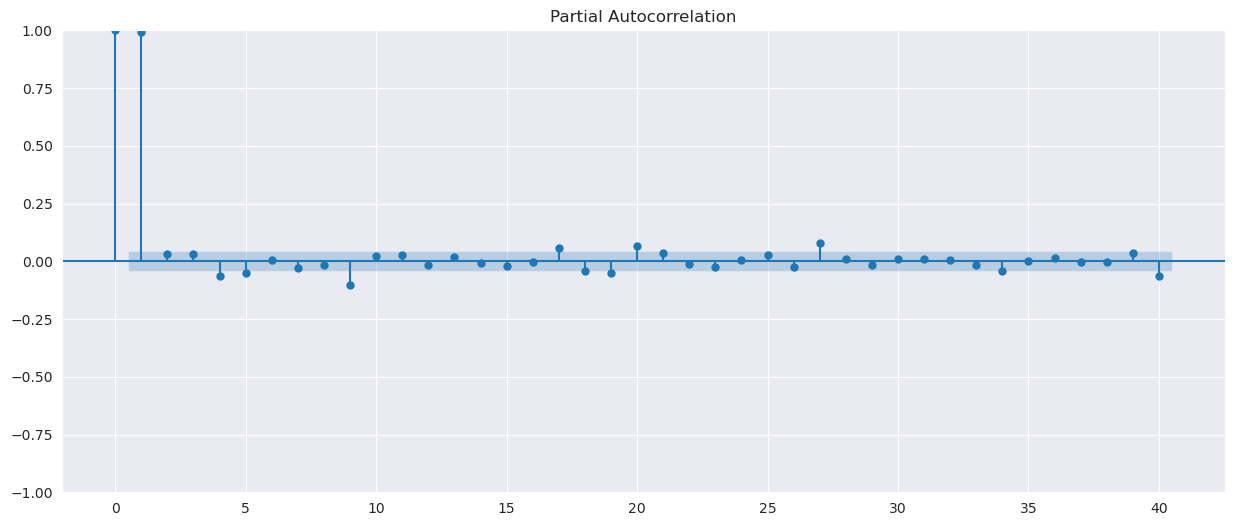

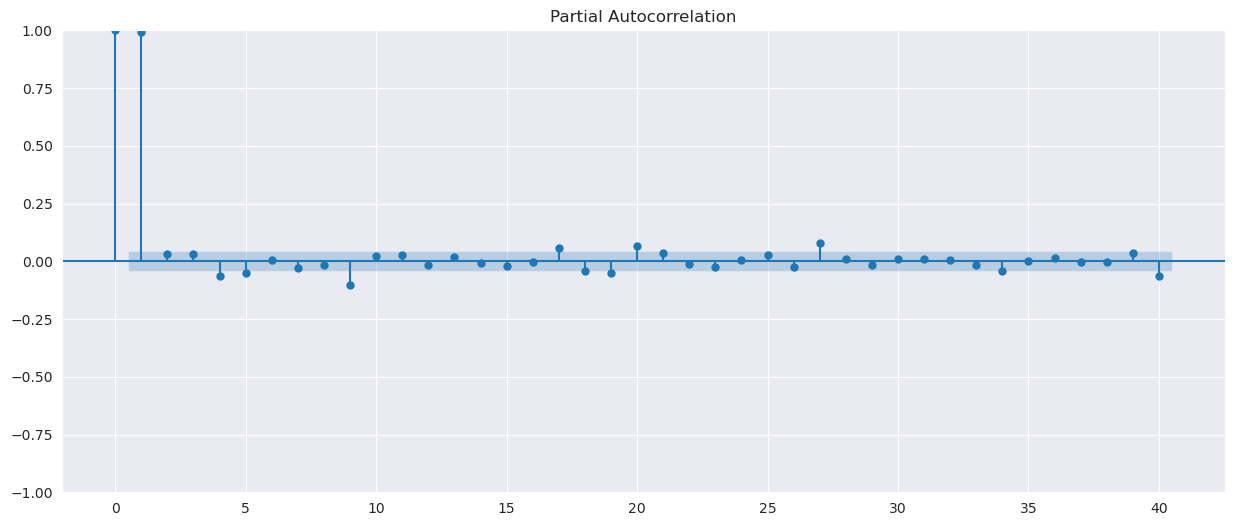

In [8]:
# serial dependence
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(y_deseason,ax=ax, lags=40, use_vlines=True)

In [9]:
def make_lags(ts, lags):
    return pd.concat(
        {
            f'y_lag_{i}': ts.shift(i)
            for i in range(1, lags + 1)
        },
        axis=1)

- feature matrix

In [10]:
X_lags = make_lags(y_deseason, 1)
X = pd.concat([X_time, X_lags], axis=1).dropna()
y, X = y.align(X, join='outer')
X.columns = X.columns.astype(str)
X.bfill(inplace=True)
X.drop('closing', axis=1, inplace=True)
y = y['closing']

In [11]:
X.head()

,"('y_lag_1', 'closing')",const,"s(10,52)","s(11,52)","s(12,52)","s(13,52)","s(14,52)","s(15,52)","s(16,52)","s(17,52)",...,"s(49,52)","s(5,52)","s(50,52)","s(51,52)","s(52,52)","s(6,52)","s(7,52)","s(8,52)","s(9,52)",trend
date,,,,,,,,,,,,,,,,,,,,,
1986-01-03,17.534152,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
1986-01-10,17.534152,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
1986-01-17,16.984396,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
1986-01-24,15.856591,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
1986-01-31,11.405859,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0


# Training time series models

In [12]:
from sklearn.model_selection import train_test_split


X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, shuffle=False)

model = LinearRegression(fit_intercept=False).fit(X_train, y_train)
y_fit = pd.Series(model.predict(X_train), index=X_train.index).clip(0.0)
y_pred = pd.Series(model.predict(X_valid), index=X_valid.index).clip(0.0)

rmsle_train = mean_squared_log_error(y_train, y_fit) ** 0.5
rmsle_valid = mean_squared_log_error(y_valid, y_pred) ** 0.5
print(f'Training RMSLE: {rmsle_train:.5f}')
print(f'Validation RMSLE: {rmsle_valid:.5f}')

Training RMSLE: 0.05225
Validation RMSLE: 0.06089


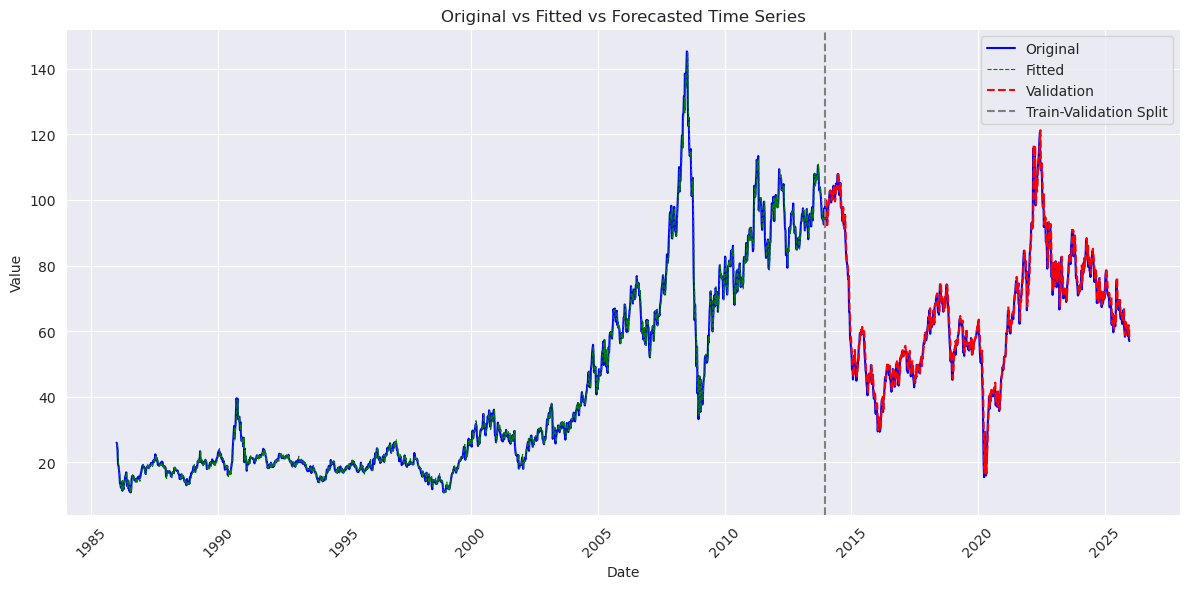

In [13]:
df_plot = pd.DataFrame({
    'Original': pd.concat([y_train, y_valid]),
    'Fitted': pd.concat([y_fit, pd.Series([np.nan] * len(y_valid), index=y_valid.index)]),  # NaN for validation period
    'Forecasted': pd.concat([pd.Series([np.nan] * len(y_train), index=y_train.index), y_pred])  # NaN for training period
})

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Plot original values
ax.plot(df_plot.index, df_plot['Original'], label='Original', color='blue',)

# Plot fitted values (only for training period)
ax.plot(df_plot.index, df_plot['Fitted'], label='Fitted', color='green', linestyle='--', linewidth=0.8)
ax.set(xlabel='Date', ylabel='Value')

# Plot forecasted values (only for validation period)
ax.plot(df_plot.index, df_plot['Forecasted'], label='Validation', color='red', linestyle='--')

# Add vertical line to separate training and validation periods
ax.axvline(x=y_train.index[-1], color='gray', linestyle='--', label='Train-Validation Split')

# Add labels and title
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.set_title('Original vs Fitted vs Forecasted Time Series')
ax.legend()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

# Making the time series stationary and then retraining the model

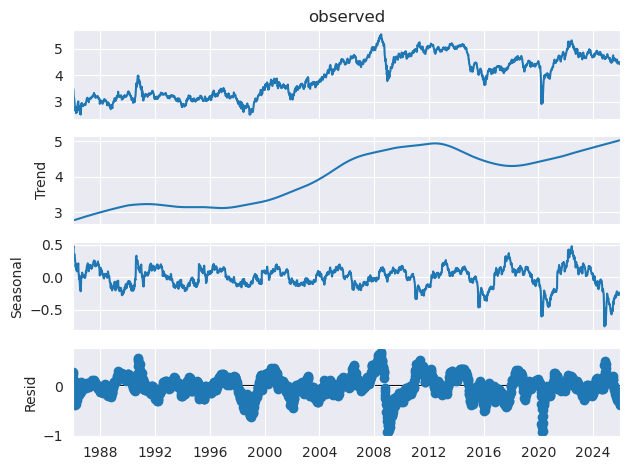

In [14]:
res = MSTL(df, periods=5*4*12, lmbda='auto' ).fit()
res.plot()
plt.tight_layout()
plt.show()

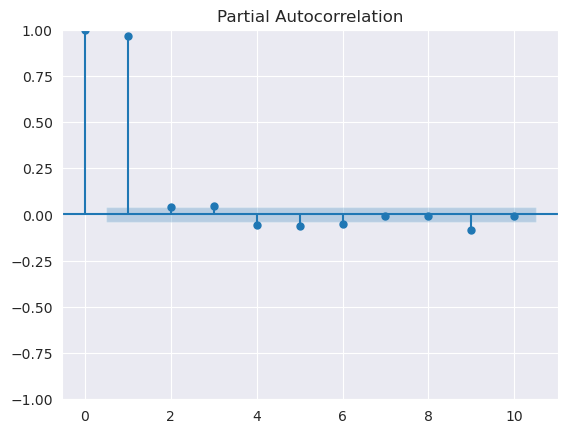

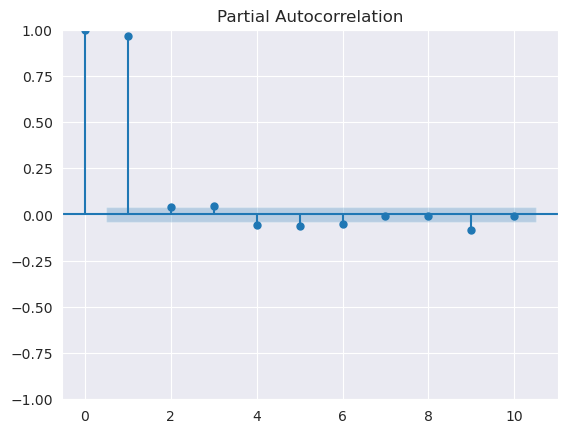

In [15]:
plot_pacf(res._resid, lags=10)

- the residual value still doesn't seem stationary enough, therefore we will take the first difference of the residual

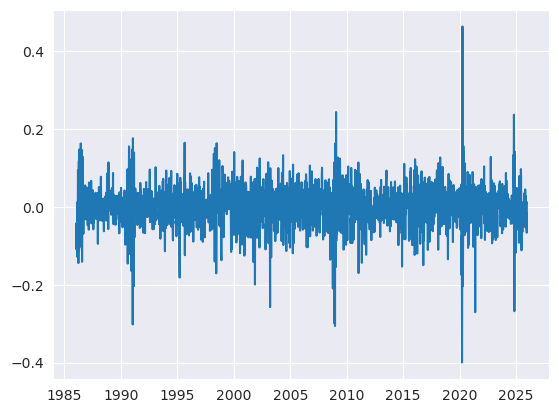

In [16]:
y_stationary = res._resid.diff()
plt.plot(y_stationary)

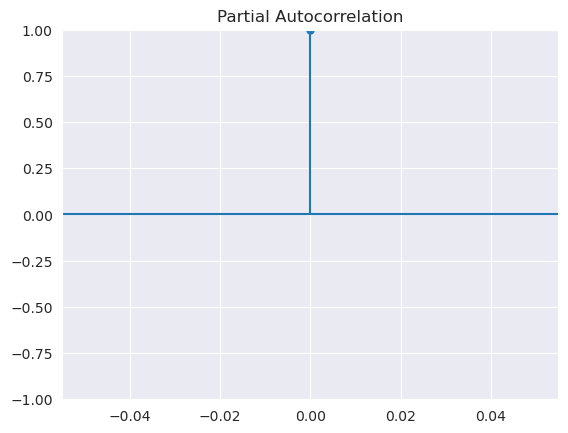

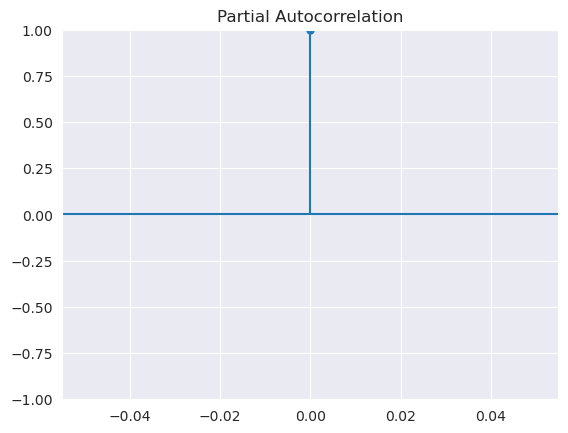

In [17]:
plot_pacf(y_stationary, lags=10)

- now we will retrain the model with the stationary series as a new feature along with the temporal features created earlier

In [18]:
y_stationary.fillna(value=y_stationary.mean(), inplace=True)
X = pd.concat([X, y_stationary], axis=1)
y, X = y.align(X, join='outer')
X.columns = X.columns.astype(str)
X.bfill(inplace=True)

- new feature matrix concatenated with the oil price stationary process

In [19]:
X.head()

,"('y_lag_1', 'closing')",const,"s(10,52)","s(11,52)","s(12,52)","s(13,52)","s(14,52)","s(15,52)","s(16,52)","s(17,52)",...,"s(5,52)","s(50,52)","s(51,52)","s(52,52)","s(6,52)","s(7,52)","s(8,52)","s(9,52)",trend,resid
date,,,,,,,,,,,,,,,,,,,,,
1986-01-03,17.534152,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,-0.000317
1986-01-10,17.534152,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,-0.042778
1986-01-17,16.984396,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,-0.108608
1986-01-24,15.856591,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,-0.066959
1986-01-31,11.405859,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,-0.055437


- Retraining the model

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, shuffle=False)

model = LinearRegression(fit_intercept=False).fit(X_train, y_train)
y_fit = pd.Series(model.predict(X_train), index=X_train.index).clip(0.0)
y_pred = pd.Series(model.predict(X_valid), index=X_valid.index).clip(0.0)

rmsle_train = mean_squared_log_error(y_train, y_fit) ** 0.5
rmsle_valid = mean_squared_log_error(y_valid, y_pred) ** 0.5
print(f'Training RMSLE: {rmsle_train:.5f}')
print(f'Validation RMSLE: {rmsle_valid:.5f}')

Training RMSLE: 0.04527
Validation RMSLE: 0.03451


- Therefore, we can confirm that the model performs better when the process is stationary

# Comparing this with ARIMA

In [21]:
df = df.reset_index()
df["unique_id"]="1"
df.columns=["ds", "y", "unique_id"]
df.head()

,ds,y,unique_id
0,1986-01-03,26.00,1
1,1986-01-10,25.65,1
2,1986-01-17,23.63,1
3,1986-01-24,19.45,1
4,1986-01-31,18.95,1


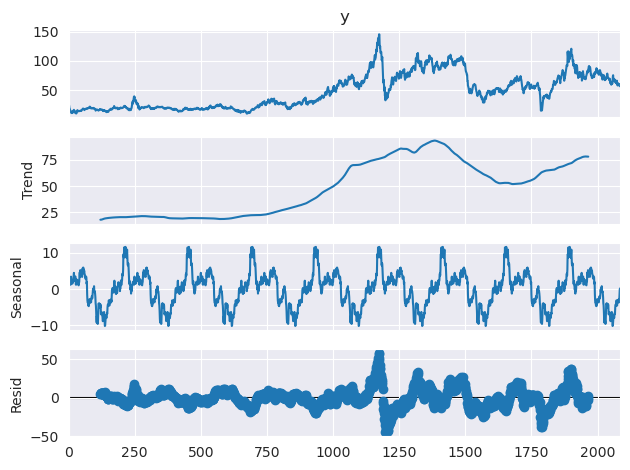

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose
a = seasonal_decompose(df["y"], model = "add", period=4*12*5)
a.plot();

In [25]:
from sklearn.model_selection import train_test_split


X_train, X_valid, Y_train_df, Y_test_df = train_test_split(X, df, test_size=0.3, shuffle=False)
Y_train_df.shape, Y_test_df.shape

((1460, 3), (626, 3))

In [26]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import arima_string

In [27]:
horizon = len(Y_test_df) # number of predictions
models = [AutoARIMA()]

In [28]:
sf = StatsForecast(models=models, freq='W')
sf.fit(df=Y_train_df)
arima_string(sf.fitted_[0,0].model_)

'ARIMA(2,1,2)                   '

In [29]:
result=sf.fitted_[0,0].model_
print(result.keys())
print(result['arma'])

dict_keys(['coef', 'sigma2', 'var_coef', 'mask', 'loglik', 'aic', 'arma', 'residuals', 'code', 'n_cond', 'nobs', 'model', 'bic', 'aicc', 'ic', 'xreg', 'x', 'lambda'])
(2, 2, 0, 0, 1, 1, 0)


In [30]:
residual=pd.DataFrame(result.get("residuals"), columns=["residual Model"])
residual

,residual Model
0,0.026000
1,-0.348267
2,-2.021707
3,-4.220064
4,-0.596569
...,...
1455,1.156449
1456,-1.503041
1457,5.259054
1458,-0.702970


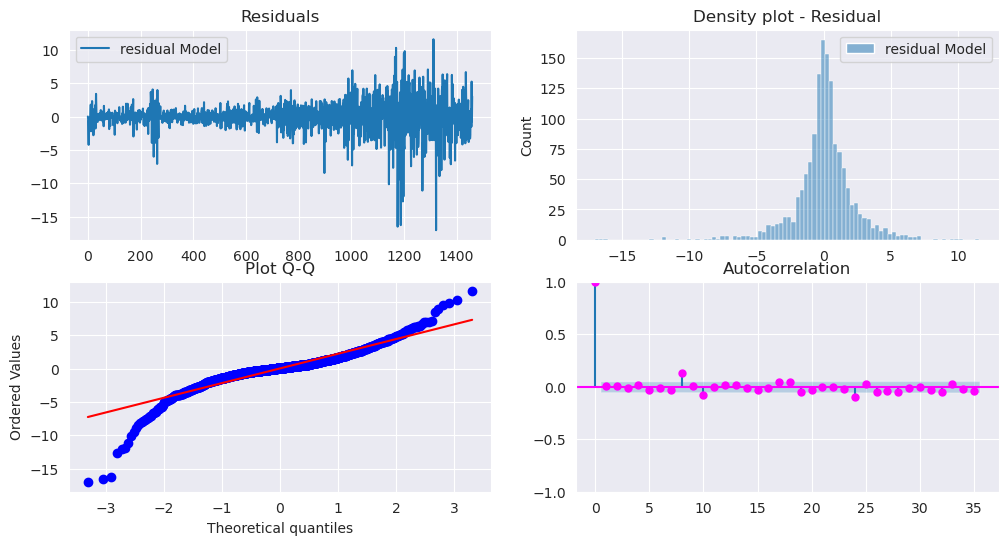

In [31]:
import seaborn as sns
import scipy.stats as stats

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 6))

# plot[1,1]
residual.plot(ax=axs[0,0])
axs[0,0].set_title("Residuals")

# plot
sns.histplot(residual, ax=axs[0,1])
axs[0,1].set_title("Density plot - Residual")

# plot
stats.probplot(residual["residual Model"], dist="norm", plot=axs[1,0])
axs[1,0].set_title('Plot Q-Q')

# plot
plot_acf(residual,  lags=35, ax=axs[1,1],color="fuchsia")
axs[1,1].set_title("Autocorrelation")

plt.show();

In [32]:
Y_hat_df = sf.forecast(df=Y_train_df, h=horizon, fitted=True)
Y_hat_df['ds'] = Y_hat_df['ds'] + pd.Timedelta(days=5)
Y_hat_df.head()

,unique_id,ds,AutoARIMA
0,1,2013-12-27,98.932674
1,1,2014-01-03,98.979377
2,1,2014-01-10,99.152245
3,1,2014-01-17,99.381476
4,1,2014-01-24,99.620656


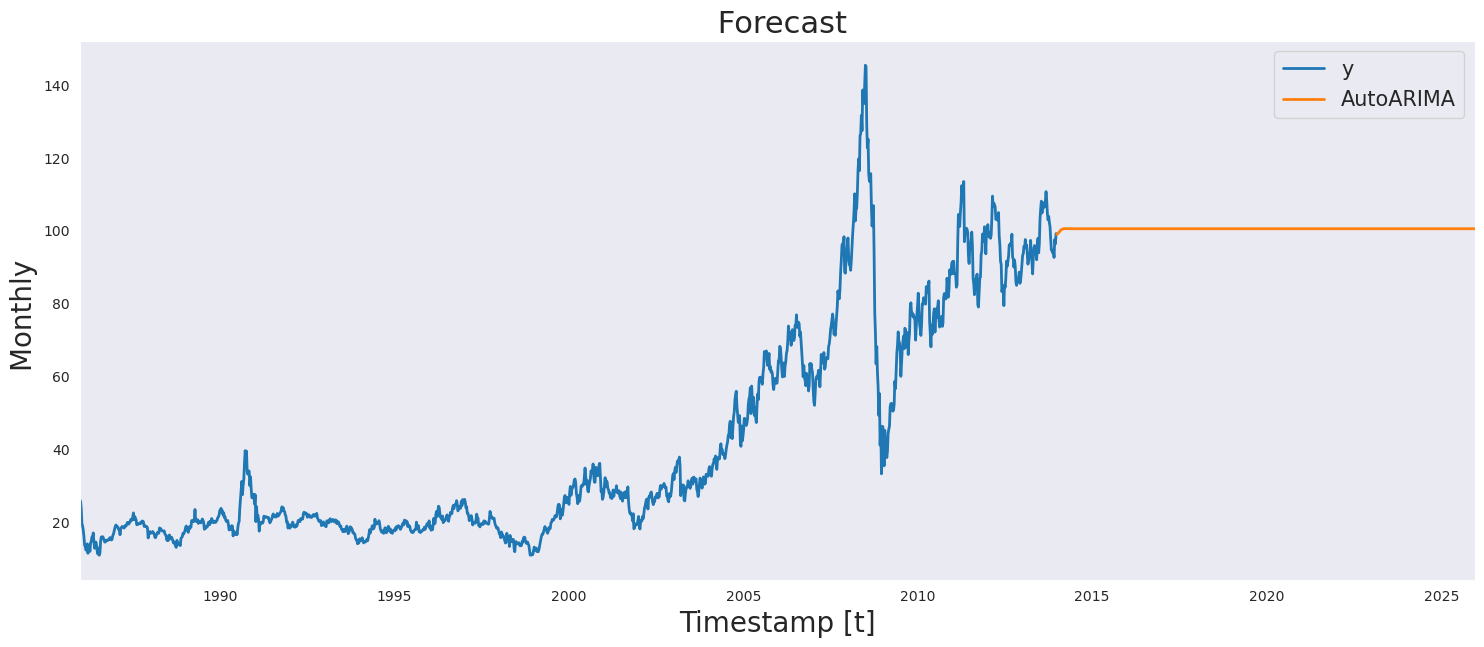

In [33]:
fig, ax = plt.subplots(1, 1, figsize = (18, 7))
plot_df = pd.concat([Y_train_df, Y_hat_df]).set_index('ds')
plot_df[['y', 'AutoARIMA']].plot(ax=ax, linewidth=2)
ax.set_title(' Forecast', fontsize=22)
ax.set_ylabel('Monthly ', fontsize=20)
ax.set_xlabel('Timestamp [t]', fontsize=20)
ax.legend(prop={'size': 15})
ax.grid()

In [34]:
from functools import partial
import utilsforecast.losses as ufl
from utilsforecast.evaluation import evaluate

evaluate(
    Y_test_df.merge(Y_hat_df),
    metrics=[ufl.mae, ufl.mape, ufl.rmse, partial(ufl.mase, seasonality=4*12*5), ufl.smape],
    train_df=Y_train_df,
)

,unique_id,metric,AutoARIMA
0,1,mae,36.063939
1,1,mape,0.710203
2,1,rmse,40.238011
3,1,mase,2.126896
4,1,smape,0.233199
